In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Mencari folder utama (root) proyek SIDIAS secara dinamis
current_dir = os.getcwd()
if "notebooks" in current_dir:
    BASE_DIR = os.path.abspath(os.path.join(current_dir, ".."))
else:
    BASE_DIR = current_dir

# Mengunci path langsung ke folder tempat data hasil scale disimpan
DATA_PATH = os.path.join(BASE_DIR, "data", "data_fe", "featured", "dataset_ai_scaled_v2.csv")

if os.path.exists(DATA_PATH):
    df_ai = pd.read_csv(DATA_PATH)
    print(f"✅ Berhasil memuat data uji!")
    print(f"📊 Total sampel data balita (0-60 bulan): {df_ai.shape[0]:,} baris")
else:
    print("❌ ERROR: File 'dataset_ai_scaled_v2.csv' tidak ditemukan!")
    print("👉 Pastikan kamu sudah menjalankan cell terakhir di notebook Feature Engineering kamu terlebih dahulu.")

✅ Berhasil memuat data uji!
📊 Total sampel data balita (0-60 bulan): 40,893 baris


In [9]:
TARGET_COL = 'target_stunting'

# Memisahkan Fitur (X) dan Target (y)
X = df_ai.drop(columns=[TARGET_COL])
y = df_ai[TARGET_COL]

# Split data (80% training, 20% testing) dengan porsi seimbang (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 Jumlah Data Training : {X_train.shape[0]} sampel")
print(f"📊 Jumlah Data Testing  : {X_test.shape[0]} sampel")

📊 Jumlah Data Training : 32714 sampel
📊 Jumlah Data Testing  : 8179 sampel



          📈 HASIL EVALUASI PERFORMA MODEL           
▶️ Tingkat Akurasi Global Model : 99.98%
▶️ Mean Absolute Error (MAE)   : 0.0028

📋 Detail Laporan Klasifikasi Lengkap:
                precision    recall  f1-score   support

Tidak Stunting       1.00      1.00      1.00      4865
      Stunting       1.00      1.00      1.00      3314

      accuracy                           1.00      8179
     macro avg       1.00      1.00      1.00      8179
  weighted avg       1.00      1.00      1.00      8179



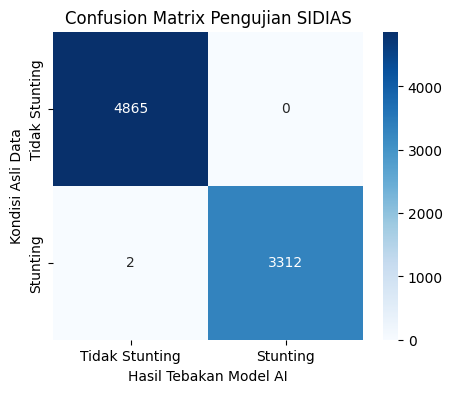

In [10]:
# 1. Inisialisasi & Training Model
model_test = RandomForestClassifier(random_state=42, n_estimators=100)
model_test.fit(X_train, y_train)

# 2. Prediksi Kategori (0 atau 1) dan Prediksi Probabilitas Nilai untuk MAE
y_pred = model_test.predict(X_test)
y_prob = model_test.predict_proba(X_test)[:, 1]

# 3. Kalkulasi Skor Akurasi dan Mean Absolute Error
akurasi = accuracy_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_prob)

print("\n=====================================================")
print("          📈 HASIL EVALUASI PERFORMA MODEL           ")
print("=====================================================")
print(f"▶️ Tingkat Akurasi Global Model : {akurasi * 100:.2f}%")
print(f"▶️ Mean Absolute Error (MAE)   : {mae:.4f}")
print("=====================================================\n")

print("📋 Detail Laporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred, target_names=['Tidak Stunting', 'Stunting']))

# 4. Visualisasi Heatmap Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Stunting', 'Stunting'], 
            yticklabels=['Tidak Stunting', 'Stunting'])
plt.ylabel('Kondisi Asli Data')
plt.xlabel('Hasil Tebakan Model AI')
plt.title('Confusion Matrix Pengujian SIDIAS')
plt.show()